<a href="https://colab.research.google.com/github/abhuvan345/6thSem-ML-Lab/blob/main/week3/1BM24CS403_LAB_3_LOGISTIC_REGRESSION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [143]:
import csv
import math
import random
from google.colab import files

# -----------------------------
# Upload Dataset
# -----------------------------
uploaded = files.upload()

# -----------------------------
# Load Dataset
# -----------------------------
X = []
y = []

with open("HR_comma_sep.csv", "r") as file:
    reader = csv.DictReader(file)

    for row in reader:
        satisfaction = float(row['satisfaction_level'])
        evaluation = float(row['last_evaluation'])
        hours = float(row['average_montly_hours'])
        projects = float(row['number_project'])
        salary = row['salary']

        # Encode salary
        if salary == "low":
            salary = 0
        elif salary == "medium":
            salary = 1
        else:
            salary = 2

        X.append([satisfaction, evaluation, hours, projects, salary])
        y.append(int(row['left']))

print("Dataset Loaded. Total samples:", len(X))

# -----------------------------
# Feature Normalization
# -----------------------------
def normalize(X):
    n_features = len(X[0])
    mins = [min(row[i] for row in X) for i in range(n_features)]
    maxs = [max(row[i] for row in X) for i in range(n_features)]

    for row in X:
        for i in range(n_features):
            if maxs[i] - mins[i] != 0:
                row[i] = (row[i] - mins[i]) / (maxs[i] - mins[i])
    return X

X = normalize(X)

# Add bias term
for i in range(len(X)):
    X[i] = [1] + X[i]

# -----------------------------
# Train/Test Split (80/20)
# -----------------------------
data = list(zip(X, y))
random.shuffle(data)

split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

X_train = [item[0] for item in train_data]
y_train = [item[1] for item in train_data]

X_test = [item[0] for item in test_data]
y_test = [item[1] for item in test_data]

# -----------------------------
# Sigmoid Function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

# -----------------------------
# Prediction
# -----------------------------
def predict_prob(x, weights):
    z = sum(x[i] * weights[i] for i in range(len(weights)))
    return sigmoid(z)

def predict(x, weights):
    return 1 if predict_prob(x, weights) >= 0.5 else 0

# -----------------------------
# Training (Gradient Descent)
# -----------------------------
def train(X, y, lr=0.1, epochs=1000):
    m = len(X)
    n = len(X[0])
    weights = [0.0] * n

    for epoch in range(epochs):
        gradients = [0.0] * n

        for i in range(m):
            y_hat = predict_prob(X[i], weights)
            error = y_hat - y[i]

            for j in range(n):
                gradients[j] += error * X[i][j]

        for j in range(n):
            weights[j] -= (lr / m) * gradients[j]

        if epoch % 200 == 0:
            print("Epoch:", epoch)

    return weights

# -----------------------------
# Accuracy
# -----------------------------
def accuracy(X, y, weights):
    correct = 0
    for i in range(len(X)):
        if predict(X[i], weights) == y[i]:
            correct += 1
    return correct / len(X)

# -----------------------------
# Confusion Matrix
# -----------------------------
def confusion_matrix(X, y, weights):
    TP = TN = FP = FN = 0

    for i in range(len(X)):
        pred = predict(X[i], weights)
        actual = y[i]

        if pred == 1 and actual == 1:
            TP += 1
        elif pred == 0 and actual == 0:
            TN += 1
        elif pred == 1 and actual == 0:
            FP += 1
        else:
            FN += 1

    return TP, TN, FP, FN

# -----------------------------
# Train Model
# -----------------------------
weights = train(X_train, y_train, lr=0.5, epochs=1000)

# -----------------------------
# Evaluate
# -----------------------------
train_acc = accuracy(X_train, y_train, weights)
test_acc = accuracy(X_test, y_test, weights)

print("\nFinal Weights:", weights)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

TP, TN, FP, FN = confusion_matrix(X_test, y_test, weights)

print("\nConfusion Matrix")
print("TP:", TP, "FP:", FP)
print("FN:", FN, "TN:", TN)

Saving HR_comma_sep.csv to HR_comma_sep (3).csv
Dataset Loaded. Total samples: 14999
Epoch: 0
Epoch: 200
Epoch: 400
Epoch: 600
Epoch: 800

Final Weights: [0.7123018702720643, -3.663165796532375, 0.5181621343009649, 0.8401328168741562, -1.025454861322558, -1.2605908093083429]
Training Accuracy: 0.7835652971080923
Testing Accuracy: 0.7726666666666666

Confusion Matrix
TP: 167 FP: 131
FN: 551 TN: 2151


In [144]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("HR_comma_sep.csv")
df.head()

Saving HR_comma_sep.csv to HR_comma_sep (4).csv


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


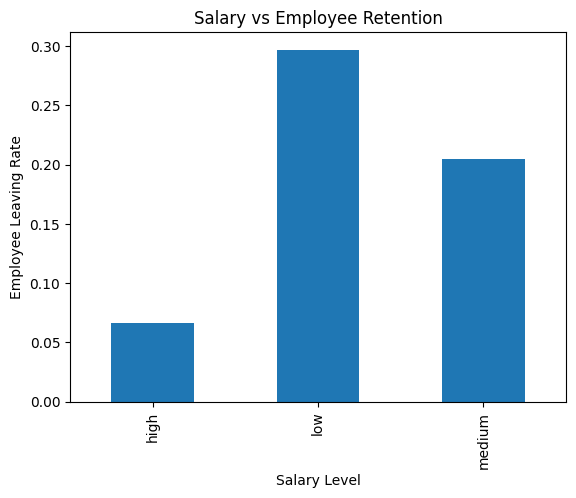

In [145]:
salary_retention = df.groupby("salary")["left"].mean()

plt.figure()
salary_retention.plot(kind="bar")
plt.xlabel("Salary Level")
plt.ylabel("Employee Leaving Rate")
plt.title("Salary vs Employee Retention")
plt.show()

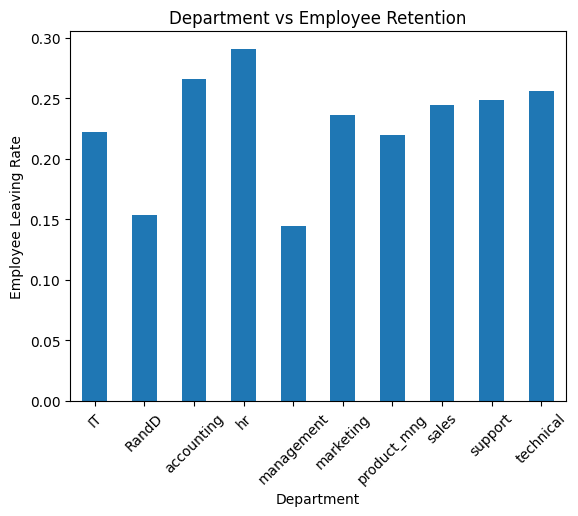

In [146]:
dept_retention = df.groupby("Department")["left"].mean()

plt.figure()
dept_retention.plot(kind="bar")
plt.xlabel("Department")
plt.ylabel("Employee Leaving Rate")
plt.title("Department vs Employee Retention")
plt.xticks(rotation=45)
plt.show()